In [74]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from gda import GaussianDiscriminantAnalysis



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [75]:
def load_data():
    
    X = np.loadtxt("../data/Q4/q4x.dat")
    y = np.loadtxt("../data/Q4/q4y.dat", dtype=str)
    y = np.where(y == 'Canada', 1, 0)
    return X, y



In [76]:
def plot_data_Initial(X, y):
    
    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label="Alaska", marker="o")
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label="Canada", marker="x")
    plt.xlabel("x1 (fresh water)")
    plt.ylabel("x2 (marine water)")
    plt.legend()
    plt.title("Initial Data Distribution")
    plt.show()

def plot_data_Norm(X, y):

    X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label="Alaska", marker="o")
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label="Canada", marker="x")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.title("Normalized Data Distribution")
    plt.show()

def plot_result(X, y, predictions):
    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label="Alaska", marker="o", alpha=0.4)
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label="Canada", marker="x", alpha=0.4)
    plt.scatter(X[predictions == 0][:, 0], X[predictions == 0][:, 1], label="Predicted Alaska", marker="+", alpha=0.8)
    plt.scatter(X[predictions == 1][:, 0], X[predictions == 1][:, 1], label="Predicted Canada", marker=".", alpha=0.8)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.title("Predictions vs True Labels")
    plt.show()
    


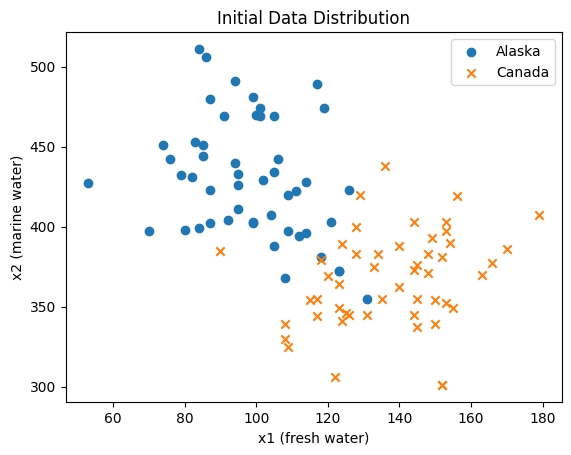

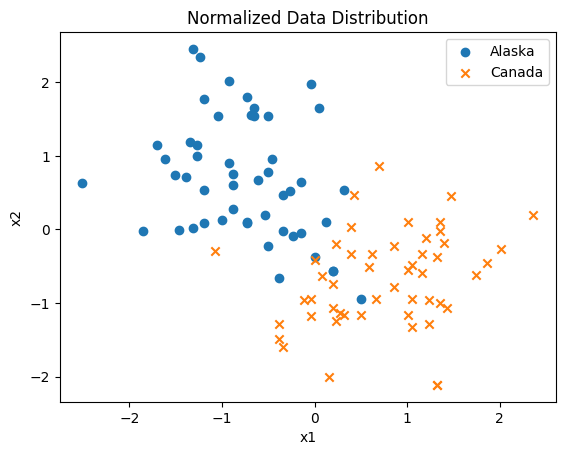

In [84]:
plot_data_Initial(*load_data())
plot_data_Norm(*load_data())

In [ ]:

def plot_theoretical_boundary(model, X, y, title="GDA Decision Boundary"):
    X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
    
    if X.shape[1] != 2:
        raise ValueError("This function only works for 2D data")
    
    plt.figure(figsize=(8, 8))
    
    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label="Alaska", marker="o", alpha=1)
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label="Canada", marker="x", alpha=1)
    
    # Plot means
    for i, mean in enumerate(model.mu):
        plt.scatter(mean[0], mean[1], c='black', marker='*', s=200, label=f'Mean class {i}')



    # For the line ax + by + c = 0
    inv_sigma = np.linalg.inv(model.sigma[0])
    diff_mu = model.mu[1] - model.mu[0]
    

    w = inv_sigma @ diff_mu
    

    b = -0.5 * (model.mu[1].T @ inv_sigma @ model.mu[1] - model.mu[0].T @ inv_sigma @ model.mu[0])
    
    print("w")
    print(w)
    print(b)
    if model.class_prior is not None:
        b += np.log(model.class_prior[1] / model.class_prior[0])
    

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    

    if abs(w[0]) < 1e-10:
        x_boundary = np.array([b/w[1], b/w[1]])
        y_boundary = np.array([x_min, x_max])
    else:
        x_boundary = np.array([x_min, x_max])
        # y = -(w[0]x + b)/w[1]
        y_boundary = -(w[0] * x_boundary + b) / w[1]
    
    # Plot decision boundary
    plt.plot(x_boundary, y_boundary, 'k-', linewidth=2, 
            label='Theoretical Boundary')
    

    plt.xlabel('x0')
    plt.ylabel('x1')
    plt.title(title)
    plt.legend()
    
  
    plt.xlim(-2, 2)
    plt.ylim(-2, 2)
    

    for i in range(2):
        x = np.linspace(-3, 3, 100)
        y = np.linspace(-3, 3, 100)
        X, Y = np.meshgrid(x, y)
        Z = np.zeros(X.shape)
        for j in range(X.shape[0]):
            for k in range(X.shape[1]):
                Z[j, k] = model.pdf(np.array([X[j, k], Y[j, k]]), i)
        plt.contour(X, Y, Z, levels=10, alpha=0.5)
    

    plt.show()

In [ ]:
def plot_quadratic_boundary(model, X, y, title="GDA Quadratic Decision Boundary"):
    X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
    
   
    plt.figure(figsize=(8, 8))
    
    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label="Alaska", marker="o", alpha=1)
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label="Canada", marker="x", alpha=1)
    

    for i, mean in enumerate(model.mu):
        plt.scatter(mean[0], mean[1], c='black', marker='*', s=200, label=f'Mean class {i}')

    

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),np.linspace(y_min, y_max, 100))
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    

    def quadratic_score(x, mu0, mu1, sigma0, sigma1, pi0, pi1):
        inv_sigma0 = np.linalg.inv(sigma0)
        inv_sigma1 = np.linalg.inv(sigma1)
        
        diff0 = x - mu0
        diff1 = x - mu1
        
        term0 = -0.5 * diff0 @ inv_sigma0 @ diff0 - 0.5 * np.log(np.linalg.det(sigma0)) + np.log(pi0)
        term1 = -0.5 * diff1 @ inv_sigma1 @ diff1 - 0.5 * np.log(np.linalg.det(sigma1)) + np.log(pi1)
        
        return term1 - term0
    
    quad_scores = np.array([
        quadratic_score(
            x, 
            model.mu[0], 
            model.mu[1], 
            model.sigma[0], 
            model.sigma[1],
            model.class_prior[0],
            model.class_prior[1]
        ) for x in grid_points
    ])
    
    quad_boundary = quad_scores.reshape(xx.shape)
    
    # Plot decision boundary
    plt.contour(xx, yy, quad_boundary, levels=[0], colors='red',linestyles='-', linewidths=2, label='Decision Boundary')


    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.legend()


    plt.xlim(-2, 2)
    plt.ylim(-2, 2)

    for i in range(2):
        x = np.linspace(-3, 3, 100)
        y = np.linspace(-3, 3, 100)
        X, Y = np.meshgrid(x, y)
        Z = np.zeros(X.shape)
        for j in range(X.shape[0]):
            for k in range(X.shape[1]):
                Z[j, k] = model.pdf(np.array([X[j, k], Y[j, k]]), i)
        plt.contour(X, Y, Z, levels=10, alpha=0.5)
    
    plt.show()

Same sigma :
m_0= [-0.75529433  0.68509431]
m_1= [ 0.75529433 -0.68509431]
sigma= [[ 0.42953048 -0.02247228]
 [-0.02247228  0.53064579]]


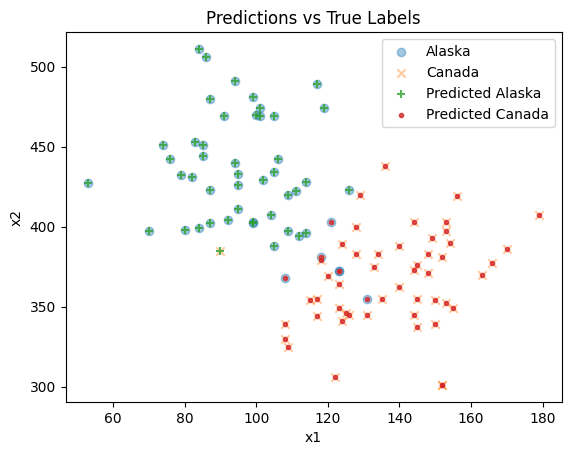

Accuracy:  0.93


/var/folders/3p/9b8ldbrj6xb36t3x4rxh31bh0000gn/T/ipykernel_44323/858473881.py:66: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Z[j, k] = model.pdf(np.array([X[j, k], Y[j, k]]), i)


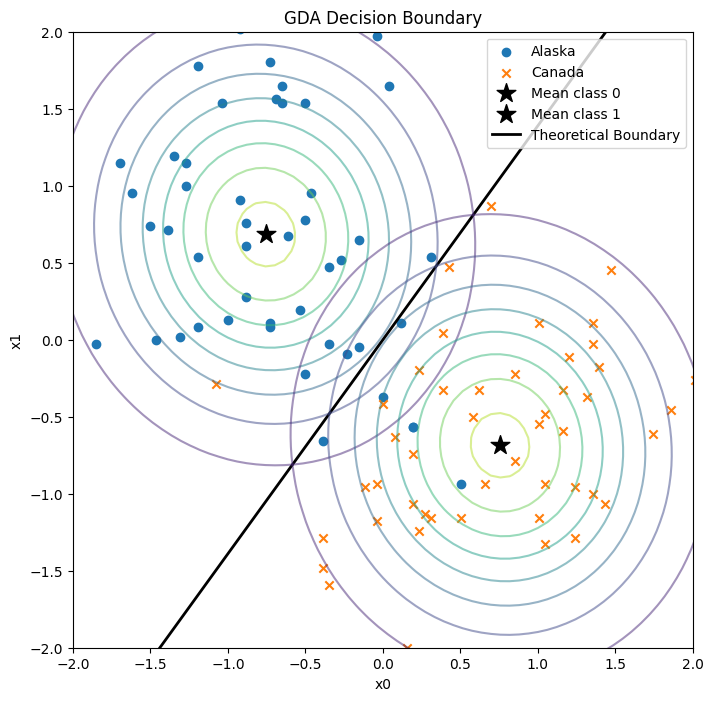

In [ ]:
X,y = load_data()

gda_shared = GaussianDiscriminantAnalysis()

Linear_Model = gda_shared.fit(X, y,True)
print("Same sigma :")
print("m_0=",Linear_Model[0])
print("m_1=",Linear_Model[1])
print("sigma=",Linear_Model[2])


predictions = gda_shared.predict(X)


plot_result(X, y, predictions)


print("Accuracy: ", np.mean(predictions == y))
plot_theoretical_boundary(gda_shared, X, y)



Same sigma :
m_0= [-0.75529433  0.68509431]
m_1= [ 0.75529433 -0.68509431]
sigma_0= [[ 0.38158978 -0.15486516]
 [-0.15486516  0.64773717]]
sigma_1= [[0.47747117 0.1099206 ]
 [0.1099206  0.41355441]]


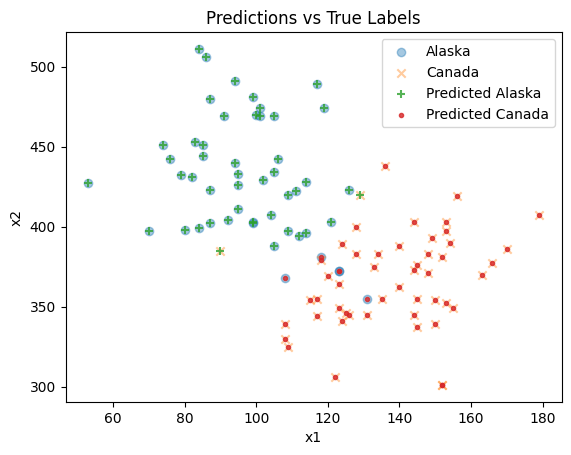

Accuracy:  0.93


/var/folders/3p/9b8ldbrj6xb36t3x4rxh31bh0000gn/T/ipykernel_44323/2732068249.py:51: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(xx, yy, quad_boundary, levels=[0], colors='red',
/var/folders/3p/9b8ldbrj6xb36t3x4rxh31bh0000gn/T/ipykernel_44323/2732068249.py:73: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Z[j, k] = model.pdf(np.array([X[j, k], Y[j, k]]), i)


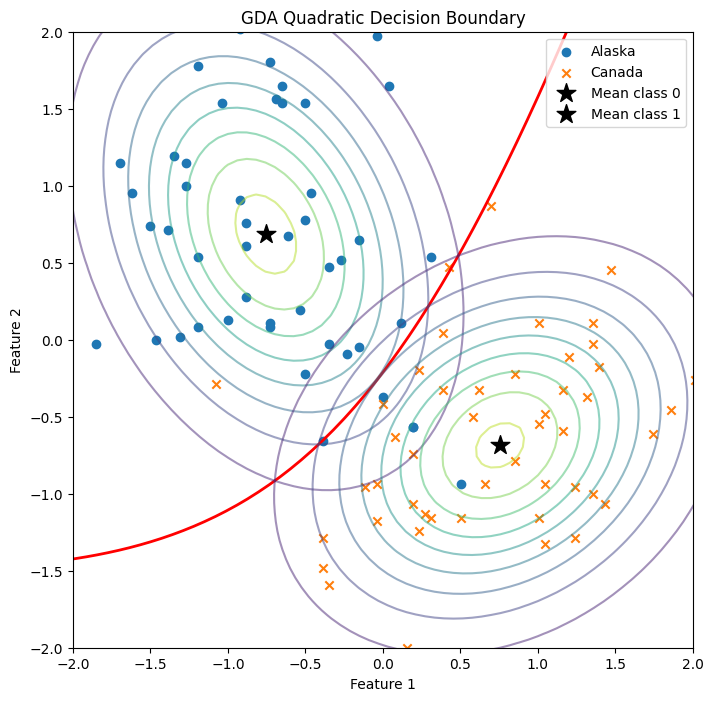

In [ ]:
X,y = load_data()

gda_separate = GaussianDiscriminantAnalysis()

Normal_Model = gda_separate.fit(X, y,False)
print("Same sigma :")
print("m_0=",Normal_Model[0])
print("m_1=",Normal_Model[1])
print("sigma_0=",Normal_Model[2])
print("sigma_1=",Normal_Model[3])


predictions = gda_separate.predict(X)


plot_result(X, y, predictions)


print("Accuracy: ", np.mean(predictions == y))
plot_quadratic_boundary(gda_separate, X, y)


In [ ]:
def plot_both_boundaries(model_shared, model_separate, X, y, title="GDA Decision Boundaries"):

    X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

    if X.shape[1] != 2:
        raise ValueError("This function only works for 2D data")
    
    
    plt.figure(figsize=(16, 16))
    
    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label="Alaska", marker="o", alpha=1)
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label="Canada", marker="x", alpha=1)
    


    
    # Create mesh grid for contour plotting
    # x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    # y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    x_min , x_max = -10 , 10
    y_min , y_max = -10 , 10
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                        np.linspace(y_min, y_max, 100))
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    
    # Linear boundary (shared covariance)
    inv_sigma = np.linalg.inv(model_shared.sigma[0])
    diff_mu = model_shared.mu[1] - model_shared.mu[0]
    w = inv_sigma @ diff_mu
    b = -0.5 * (model_shared.mu[1].T @ inv_sigma @ model_shared.mu[1] - 
                model_shared.mu[0].T @ inv_sigma @ model_shared.mu[0])
    
    if model_shared.class_prior is not None:
        b += np.log(model_shared.class_prior[1] / model_shared.class_prior[0])
    
    linear_scores = grid_points @ w + b
    linear_boundary = linear_scores.reshape(xx.shape)
    
    # Quadratic boundary (separate covariances)
    def quadratic_score(x, mu0, mu1, sigma0, sigma1, pi0, pi1):
        inv_sigma0 = np.linalg.inv(sigma0)
        inv_sigma1 = np.linalg.inv(sigma1)
        
        diff0 = x - mu0
        diff1 = x - mu1
        
        term0 = -0.5 * diff0 @ inv_sigma0 @ diff0 - 0.5 * np.log(np.linalg.det(sigma0)) + np.log(pi0)
        term1 = -0.5 * diff1 @ inv_sigma1 @ diff1 - 0.5 * np.log(np.linalg.det(sigma1)) + np.log(pi1)
        
        return term1 - term0
    
    quad_scores = np.array([
        quadratic_score(
            x, 
            model_separate.mu[0], 
            model_separate.mu[1], 
            model_separate.sigma[0], 
            model_separate.sigma[1],
            model_separate.class_prior[0],
            model_separate.class_prior[1]
        ) for x in grid_points
    ])
    
    quad_boundary = quad_scores.reshape(xx.shape)
    

    plt.contour(xx, yy, linear_boundary, levels=[0], colors='black', 
                linestyles='-', linewidths=2, label='Linear Boundary')
    plt.contour(xx, yy, quad_boundary, levels=[0], colors='red', 
                linestyles='--', linewidths=2, label='Quadratic Boundary')
    

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.legend()
    
    plt.show()

/var/folders/3p/9b8ldbrj6xb36t3x4rxh31bh0000gn/T/ipykernel_44323/3862152371.py:67: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(xx, yy, linear_boundary, levels=[0], colors='black',
/var/folders/3p/9b8ldbrj6xb36t3x4rxh31bh0000gn/T/ipykernel_44323/3862152371.py:69: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(xx, yy, quad_boundary, levels=[0], colors='red',


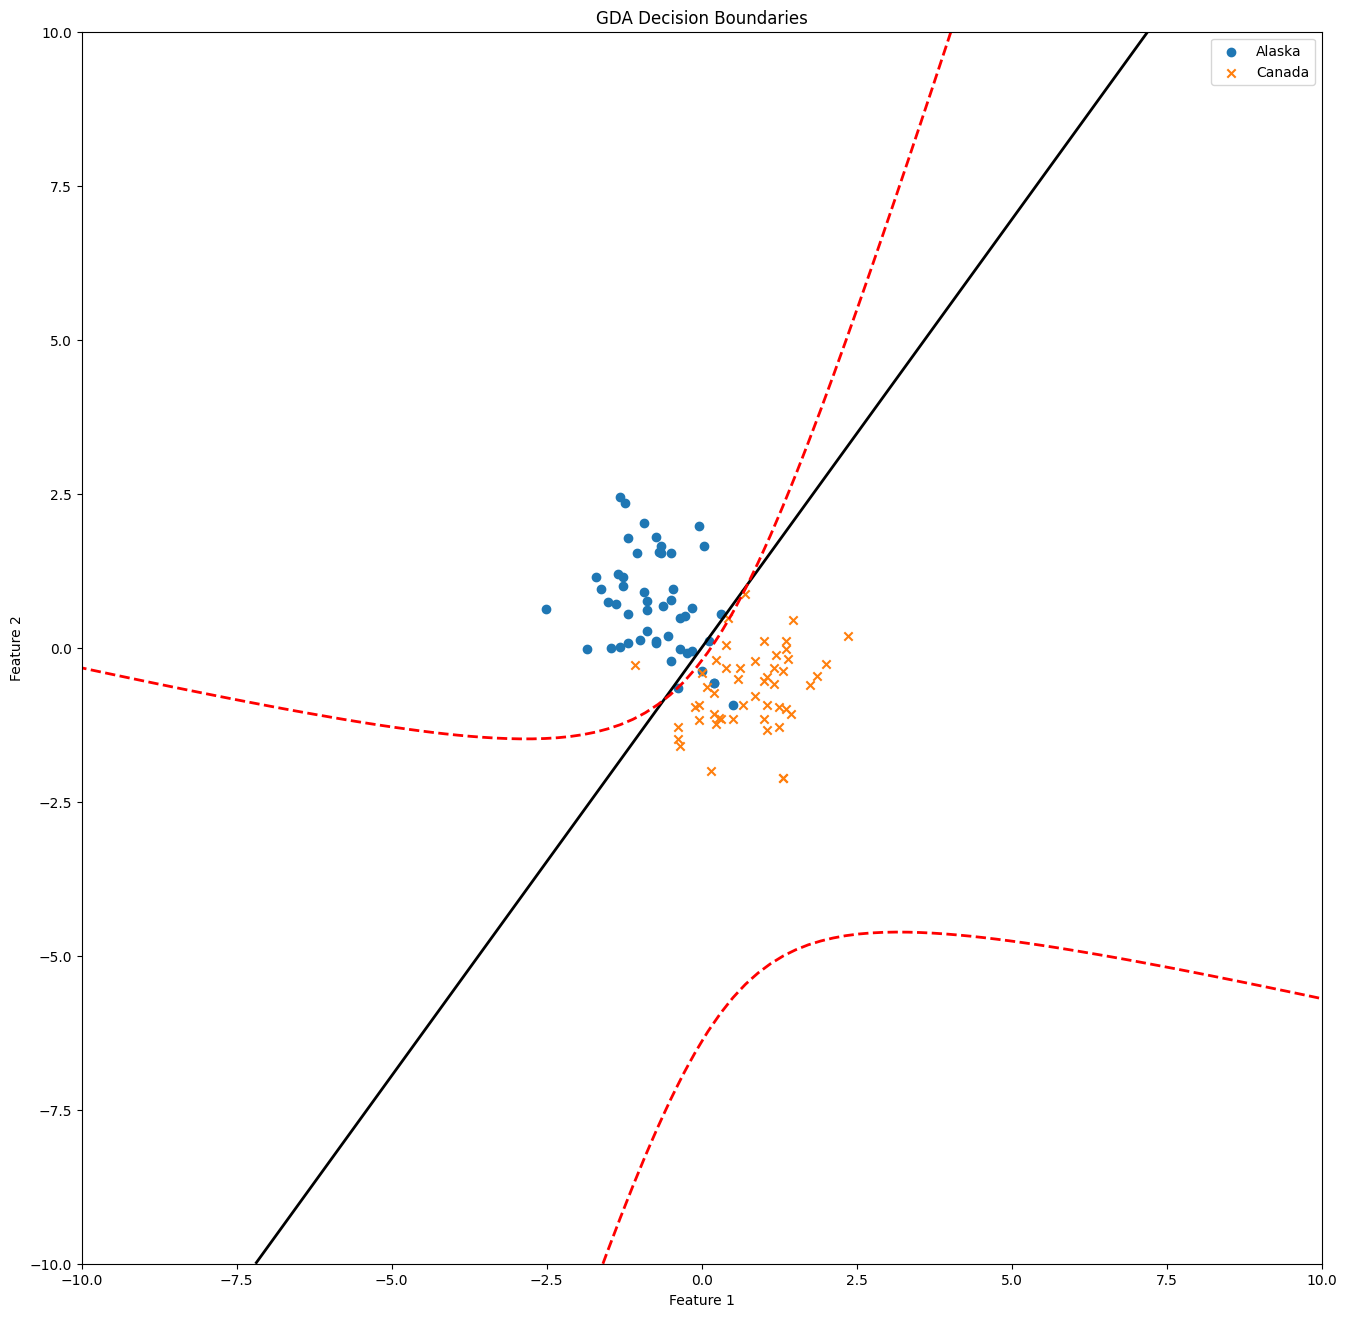

In [83]:
plot_both_boundaries(gda_shared, gda_separate, X, y)

In [ ]:

predictions = gda_shared.predict(X)
print("Accuracy for shared covariance: ", np.mean(predictions == y))

predictions = gda_separate.predict(X)
print("Accuracy for separate covariance: ", np.mean(predictions == y) )



Accuracy for shared covariance:  0.93
Accuracy for separate covariance:  0.93
